In [4]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

parks = pd.read_csv('parks_data.csv')

# Pittsburgh's Neighborhood Green Space 
---

## What this notebook does
Loads the City of Pittsburgh Parks dataset from the WPRDC.
Explores what's in the data.
Filters out beautification sites and data-entry outliers.
Sums total park acreage per maintenance division.
Visualizes the ranking and the breakdown by park type.
Normalizes the acreage to a 0–1 score so it combines into the group's metric nicely.
Names the greenest division (and its associated neighborhoods).

**Dataset source:** [City of Pittsburgh Parks — WPRDC](https://data.wprdc.org/dataset/parks1)

### Park Acreage summary

In [5]:
print(parks['acreage'].describe())
print()
print(f"Parks missing an acreage value: {parks['acreage'].isna().sum()}")
print(f"Parks missing a division:      {parks['divname'].isna().sum()}")

count    214.000000
mean      18.172722
std       74.855592
min        0.001069
25%        0.395899
50%        1.484389
75%        5.796059
max      637.409429
Name: acreage, dtype: float64

Parks missing an acreage value: 1
Parks missing a division:      39


## Clean the Data

1. **Drop the "Northeast" division.** It contains only 1 park and has no matching entry in *maintenanceresponsibility*. Almost certainly a data-entry error rather than a real seventh division.
2. **Drop rows with missing acreage or division.** Any missing acerage or division are not able to be measured.
3. **Remove "Beautification Sites."** Any landscaped traffic islands, medians and decorative corners, while technically parks in the dataset, aren't usable recreational green space.

In [6]:
#data cleaning
parks_clean = parks.copy()

parks_clean = parks_clean[parks_clean['divname'] != 'Northeast']
parks_clean = parks_clean.dropna(subset = ['acreage', 'divname'])
parks_clean = parks_clean[parks_clean['final_cat'] != 'Beautification Site']

print(f'Rows before cleaning: {len(parks)}')
print(f'Rows after cleaning: {len(parks_clean)}')
print(f'Divisions remaining: {parks_clean["divname"].nunique()}')

Rows before cleaning: 215
Rows after cleaning: 168
Divisions remaining: 6


## Compute Total Acreage per Division

The core of the sub-metric: how much usable park acreage does each division contain?

In [7]:
division_stats = (parks_clean
    .groupby('divname')
    .agg(total_acreage = ('acreage', 'sum'), park_count = ('acreage', 'size'), avg_park_size = ('acreage', 'mean'),)
    .sort_values('total_acreage', ascending = False)
    .reset_index())

division_stats = division_stats.round(2) #rounding
division_stats

,divname,total_acreage,park_count,avg_park_size
0,McKinley,1114.11,32,34.82
1,Frick,847.53,20,42.38
2,Schenley,556.83,23,24.21
3,Highland,459.06,22,20.87
4,Riverview,444.12,38,11.69
5,Emerald,413.05,33,12.52


## Visualization

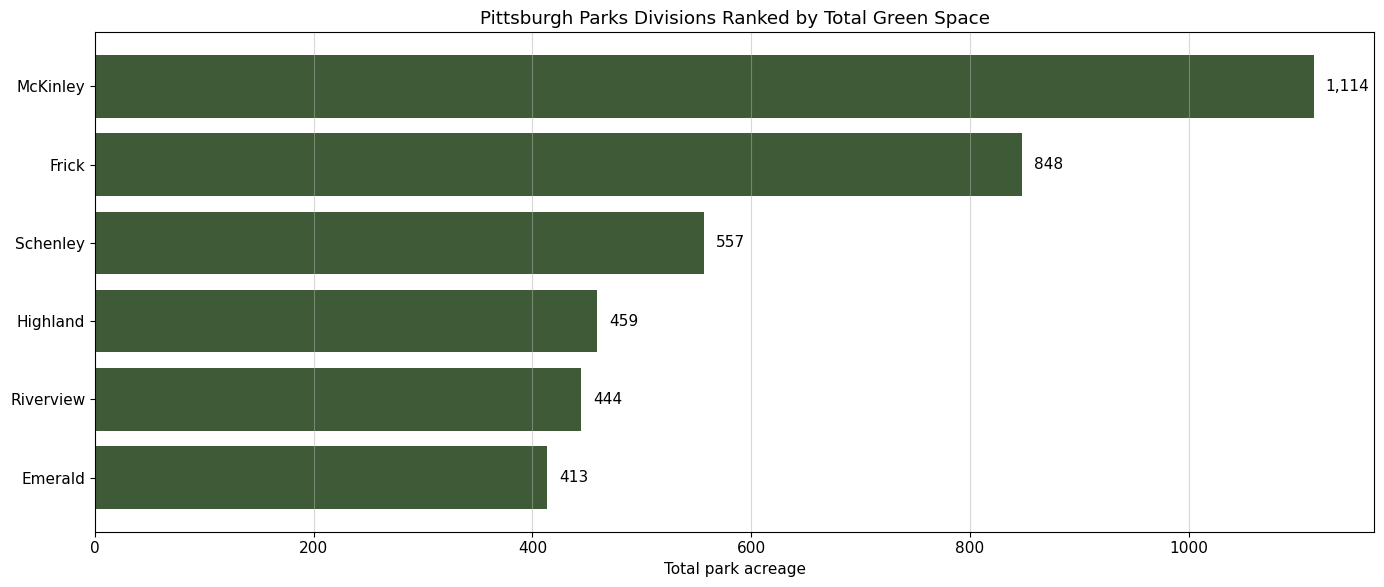

In [8]:
ranked = division_stats.sort_values('total_acreage')

fig, ax = plt.subplots(figsize = (14, 6))
bars = ax.barh(ranked['divname'], ranked['total_acreage'], color = '#3f5a36')
ax.set_xlabel('Total park acreage')
ax.set_title('Pittsburgh Parks Divisions Ranked by Total Green Space')
ax.grid(axis = 'x', alpha = 0.5)

for i, (name, acres) in enumerate(zip(ranked['divname'], ranked['total_acreage'])):
    ax.text(acres + max(ranked['total_acreage']) * 0.01, i, f'{acres:,.0f}', va='center')

plt.tight_layout()
plt.show()

### Breakdown by park type

The bar chart showing how each division's acreage splits across park categories. This reveals why a division ranks where it does, a lot of regional-park acreage vs. many small neighborhood parks tell very different stories.

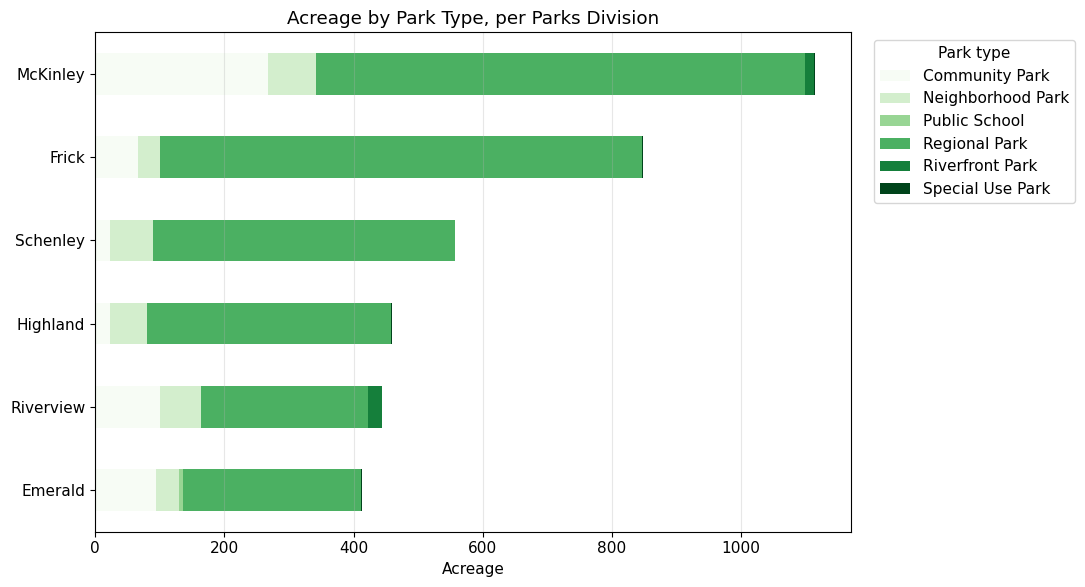

In [9]:
breakdown = (parks_clean
    .groupby(['divname', 'final_cat'])['acreage']
    .sum()
    .unstack(fill_value = 0)
)

breakdown = breakdown.loc[breakdown.sum(axis = 1).sort_values().index]

fig, ax = plt.subplots(figsize = (11, 6))
breakdown.plot(kind = 'barh', stacked = True, ax = ax, colormap = 'Greens')
ax.set_xlabel('Acreage')
ax.set_ylabel('')
ax.set_title('Acreage by Park Type, per Parks Division')
ax.legend(title = 'Park type', bbox_to_anchor = (1.02, 1), loc = 'upper left')
ax.grid(axis = 'x', alpha = 0.3)
plt.tight_layout()
plt.show()

## Normalize to a 0–1 Score

Using min-max normalization method:

$$\text{score} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

The division with the most acreage gets 1, the one with the least gets 0.

In [10]:
min_acres = division_stats['total_acreage'].min()
max_acres = division_stats['total_acreage'].max()

division_stats['green_score'] = ((division_stats['total_acreage'] - min_acres) / (max_acres - min_acres)).round(3)

division_stats

,divname,total_acreage,park_count,avg_park_size,green_score
0,McKinley,1114.11,32,34.82,1.000
1,Frick,847.53,20,42.38,0.620
2,Schenley,556.83,23,24.21,0.205
3,Highland,459.06,22,20.87,0.066
4,Riverview,444.12,38,11.69,0.044
5,Emerald,413.05,33,12.52,0.000


With the normalized scores, it is now ready to be combined with other submetrics.

In [ ]:
OUTPUT_PATH = 'green_space_scores.csv'
division_stats.to_csv(OUTPUT_PATH, index = False)
print(f'Saved {len(division_stats)} rows to {OUTPUT_PATH}')
print()
print('Preview:')
division_stats

## Expand to Neighborhood Level

The combined group notebook merges sub-metrics by neighborhood, but the data is at the division level. So by mapping each parks division to the neighborhoods it serves and giving every neighborhood inside that division the same green score. <br>

This means a neighborhood like Squirrel Hill North (which sits in the Schenley division) gets the Schenley green score, even with many other neighborhoods in that same division that share the same score. <br>

This mapping is approximate as real division boundaries don't perfectly follow neighborhood lines.

In [12]:
division_to_neighborhoods = {
    'Schenley': ['Central Oakland', 'North Oakland', 'South Oakland', 'West Oakland','Squirrel Hill North', 
                 'Squirrel Hill South','Greenfield', 'Hazelwood', 'Glen Hazel','Bloomfield', 'Friendship', 'Shadyside',],
    
    'Frick': ['Point Breeze', 'Point Breeze North', 'Regent Square','Swisshelm Park',],
    
    'Highland': ['Highland Park', 'Morningside', 'Stanton Heights','East Liberty', 'Garfield', 'Larimer','Lincoln-Lemington-Belmar', 
                 'East Hills','Homewood North', 'Homewood South', 'Homewood West',],
    
    'Riverview': ['Perry North', 'Perry South', 'Brighton Heights','Northview Heights', 'Summer Hill', 'Spring Hill-City View',
                'Marshall-Shadeland', 'Troy Hill', 'Spring Garden','Fineview', 'Central Northside', 'Allegheny Center',
                'Allegheny West', 'East Allegheny', 'Manchester', 'Chateau','California-Kirkbride', 'North Shore',],
    
    'Emerald': ['West End', 'Sheraden', 'Elliott', 'Esplen','Crafton Heights', 'Westwood', 'Oakwood','Fairywood', 'Chartiers', 
                'Chartiers City','East Carnegie', 'Ridgemont', 'Windgap', 'Banksville','Beechview', 'Brookline', 'Mount Washington',
                'Duquesne Heights',],
    
    'McKinley': ['Beltzhoover', 'Knoxville', 'Mount Oliver','Allentown', 'Arlington', 'Arlington Heights','Bon Air', 'Saint Clair', 
                 'Carrick', 'Overbrook','Hays', 'Lincoln Place', 'New Homestead','South Side Slopes', 'South Side Flats', 'South Shore',],}

rows = []
for division, nbhds in division_to_neighborhoods.items():
    for n in nbhds:
        rows.append({'neighborhood': n, 'divname': division})

div_map = pd.DataFrame(rows)
print(f'Mapped {len(div_map)} neighborhoods across {div_map["divname"].nunique()} divisions.')
div_map.head(15)

Mapped 79 neighborhoods across 6 divisions.


,neighborhood,divname
0,Central Oakland,Schenley
1,North Oakland,Schenley
2,South Oakland,Schenley
3,West Oakland,Schenley
4,Squirrel Hill North,Schenley
5,Squirrel Hill South,Schenley
6,Greenfield,Schenley
7,Hazelwood,Schenley
8,Glen Hazel,Schenley
9,Bloomfield,Schenley


In [13]:
green_by_neighborhood = div_map.merge(division_stats[['divname', 'green_score', 'total_acreage']], on = 'divname', how = 'left')

green_by_neighborhood = green_by_neighborhood[['neighborhood', 'divname', 'green_score', 'total_acreage']]

OUTPUT_PATH = 'green_space_scores_by_neighborhood.csv'
green_by_neighborhood.to_csv(OUTPUT_PATH, index = False)
print(f'Saved {len(green_by_neighborhood)} rows to {OUTPUT_PATH}')
green_by_neighborhood.head(10)

Saved 79 rows to green_space_scores_by_neighborhood.csv


,neighborhood,divname,green_score,total_acreage
0,Central Oakland,Schenley,0.205,556.83
1,North Oakland,Schenley,0.205,556.83
2,South Oakland,Schenley,0.205,556.83
3,West Oakland,Schenley,0.205,556.83
4,Squirrel Hill North,Schenley,0.205,556.83
5,Squirrel Hill South,Schenley,0.205,556.83
6,Greenfield,Schenley,0.205,556.83
7,Hazelwood,Schenley,0.205,556.83
8,Glen Hazel,Schenley,0.205,556.83
9,Bloomfield,Schenley,0.205,556.83


## The Greenest Division

*Based on total park acreage:*

In [14]:
winner = division_stats.iloc[0]
print(f"Greenest division: {winner['divname']}")
print(f"Total acreage:   {winner['total_acreage']:,.1f}")
print(f"Number of parks: {int(winner['park_count'])}")
print(f"Avg park size:   {winner['avg_park_size']:.1f} acres")
print(f"Green score:     {winner['green_score']:.3f}")

Greenest division: McKinley
Total acreage:   1,114.1
Number of parks: 32
Avg park size:   34.8 acres
Green score:     1.000



Each parks division is named after the regional park it's centered on, and it covers a cluster of Pittsburgh neighborhoods. For our group's combined analysis, here's the rough mapping (to be verified by the group):

| Division | Approximate neighborhoods covered |
|---|---|
| **Schenley** | Oakland, Squirrel Hill, Greenfield, Hazelwood |
| **Frick** | Squirrel Hill South, Point Breeze, Regent Square |
| **Highland** | Highland Park, Morningside, East Liberty, Stanton Heights |
| **Riverview** | Perry North, Observatory Hill, Brighton Heights |
| **Emerald** | West End, Sheraden, Elliott, Esplen |
| **McKinley** | Beltzhoover, Knoxville, Mt. Oliver, South Side Slopes |

*Our group will confirm these mappings when we combine sub-metrics in the main notebook.*

## Conclusion

*[Write your personal reflection here — this section is graded individually. Some prompts to get you started:]*

- Does the winning division match your intuition? Do you associate those neighborhoods with being "green"?
- **Limitations of this metric:** Acreage doesn't capture quality (is it well-maintained? safe? accessible?), and measuring at the division level is coarser than at the neighborhood level. A resident in a neighborhood with one massive regional park nearby gets a high score, but that doesn't mean the park is walkable from their front door.
- Is "total acreage" really the right measure, or does something like "acreage per capita" tell a more honest story? (We don't have population data here, but the group could combine this with census data.)
- How does this data-driven winner compare to your personal favorite Pittsburgh neighborhood? If they differ, what's the data missing?
- What did pivoting from the original plan (neighborhood-level park count) to this version teach you about working with real data?

*Your reflection goes here.*